# Group 01 — MaleBin — Task 3: Improvement, Ablation, CV & Significance
**Track 2: GCN (Image → Graph)**  
**Dataset:** MaleBin Malware Binary Greyscale Images  
**Platform:** Kaggle

## Objective
This notebook evaluates improvements to the image-to-graph classification pipeline. The experiments include CNN and GCN variants, ablation analysis, comparison with the strongest CNN baseline, multiclass evaluation metrics, five-fold stratified cross-validation, and statistical significance testing.

The experiments use a reduced epoch setting to keep the full evaluation computationally practical while preserving the same data split, preprocessing, and evaluation procedure across the compared models.


In [2]:

# 1. Imports and reproducibility
import os, io, json, time, random, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, auc
)
from scipy.stats import binomtest, wilcoxon

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:

# 2. Configuration
DATA_DIR = Path("/kaggle/input/datasets/tashiee/malebin-malware-binary-greyscale-images")
if not DATA_DIR.exists():
    DATA_DIR = Path("/kaggle/input/malebin-malware-binary-greyscale-images")

OUTPUT_DIR = Path("/kaggle/working/task3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

FAST_MODE = True
BATCH_SIZE = 64
NUM_WORKERS = min(4, os.cpu_count() or 2)

# Fixed-test experiments
FIXED_EPOCHS = 5 if FAST_MODE else 10
RESNET_EPOCHS = 6 if FAST_MODE else 10
PATIENCE = 2 if FAST_MODE else 3

# Five-fold stratified cross-validation settings
RUN_5FOLD = True
CV_EPOCHS = 3 if FAST_MODE else 6

LR = 1e-3
WEIGHT_DECAY = 1e-4
GRAPH_IMAGE_SIZE = 128
CNN_IMAGE_SIZE = 224
GRID = 8
N_CLASSES_EXPECTED = None

assert DATA_DIR.exists(), f"Dataset not found: {DATA_DIR}"
print("Dataset:", DATA_DIR)
print("FAST_MODE:", FAST_MODE, "| Fixed epochs:", FIXED_EPOCHS, "| CV epochs:", CV_EPOCHS)


Dataset: /kaggle/input/datasets/tashiee/malebin-malware-binary-greyscale-images
FAST_MODE: True | Fixed epochs: 5 | CV epochs: 3


In [4]:

# 3. Build a deduplicated manifest BEFORE splitting
def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

records = []
for folder, _, files in os.walk(DATA_DIR):
    imgs = [f for f in files if Path(f).suffix.lower() in EXTENSIONS]
    if imgs:
        label = Path(folder).relative_to(DATA_DIR).as_posix()
        for name in imgs:
            records.append({"path": str(Path(folder)/name), "filename": name, "label": label})

manifest = pd.DataFrame(records).sort_values(["label", "filename"]).reset_index(drop=True)
assert len(manifest) > 0, "No images found."

manifest["sha256"] = [sha256(p) for p in tqdm(manifest.path, desc="Hashing")]
labels_per_hash = manifest.groupby("sha256").label.nunique()
cross_class_hashes = set(labels_per_hash[labels_per_hash > 1].index)

clean = manifest.loc[
    ~manifest.sha256.isin(cross_class_hashes)
    & ~manifest.duplicated("sha256", keep="first")
].copy()

# Match Task 2 rule: retain classes with at least 10 clean samples
clean = clean[clean.label.isin(clean.label.value_counts()[lambda s: s >= 10].index)].copy()

encoder = LabelEncoder().fit(clean.label)
clean["label_id"] = encoder.transform(clean.label)

print(f"Original images: {len(manifest):,}")
print(f"Cross-class duplicate groups removed: {len(cross_class_hashes):,}")
print(f"Usable deduplicated images: {len(clean):,}")
print(f"Classes: {len(encoder.classes_)}")


Hashing:   0%|          | 0/12464 [00:00<?, ?it/s]

Original images: 12,464
Cross-class duplicate groups removed: 499
Usable deduplicated images: 9,230
Classes: 35


In [5]:

# 4. Fixed leakage-free 70/15/15 stratified split
train_df, heldout_df = train_test_split(
    clean, test_size=0.30, stratify=clean.label_id, random_state=SEED
)
val_df, test_df = train_test_split(
    heldout_df, test_size=0.50, stratify=heldout_df.label_id, random_state=SEED
)

for frame, split_name in [(train_df, "train"), (val_df, "validation"), (test_df, "test")]:
    frame["split"] = split_name

split_manifest = pd.concat([train_df, val_df, test_df], ignore_index=True)
split_manifest.to_csv(OUTPUT_DIR / "split_manifest_task3.csv", index=False)
pd.DataFrame({"label": encoder.classes_, "label_id": range(len(encoder.classes_))}).to_csv(
    OUTPUT_DIR / "label_map.csv", index=False
)

print(split_manifest.split.value_counts())
assert set(train_df.sha256).isdisjoint(set(val_df.sha256))
assert set(train_df.sha256).isdisjoint(set(test_df.sha256))
assert set(val_df.sha256).isdisjoint(set(test_df.sha256))
print("Leakage check: PASS — no duplicate SHA-256 appears across splits.")


split
train         6461
test          1385
validation    1384
Name: count, dtype: int64
Leakage check: PASS — no duplicate SHA-256 appears across splits.


In [6]:

# 5. Dataset, transformations and balanced sampling
graph_train_tf = transforms.Compose([
    transforms.Resize((GRAPH_IMAGE_SIZE, GRAPH_IMAGE_SIZE)),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])
graph_eval_tf = transforms.Compose([
    transforms.Resize((GRAPH_IMAGE_SIZE, GRAPH_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

cnn_train_tf = transforms.Compose([
    transforms.Resize((CNN_IMAGE_SIZE, CNN_IMAGE_SIZE)),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])
cnn_eval_tf = transforms.Compose([
    transforms.Resize((CNN_IMAGE_SIZE, CNN_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

class MalwareImageDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        with Image.open(row.path) as im:
            x = self.transform(im.convert("L"))
        return x, int(row.label_id)

def balanced_loader(frame, transform, batch_size=BATCH_SIZE):
    ds = MalwareImageDataset(frame, transform)
    counts = frame.label_id.value_counts()
    sample_weights = frame.label_id.map(lambda x: 1.0 / counts[x]).to_numpy()
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
    return DataLoader(ds, batch_size=batch_size, sampler=sampler,
                      num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))

def plain_loader(frame, transform, batch_size=BATCH_SIZE):
    ds = MalwareImageDataset(frame, transform)
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))

graph_train_loader = balanced_loader(train_df, graph_train_tf)
graph_val_loader = plain_loader(val_df, graph_eval_tf)
graph_test_loader = plain_loader(test_df, graph_eval_tf)

cnn_train_loader = balanced_loader(train_df, cnn_train_tf)
cnn_val_loader = plain_loader(val_df, cnn_eval_tf)
cnn_test_loader = plain_loader(test_df, cnn_eval_tf)

N_CLASSES = len(encoder.classes_)


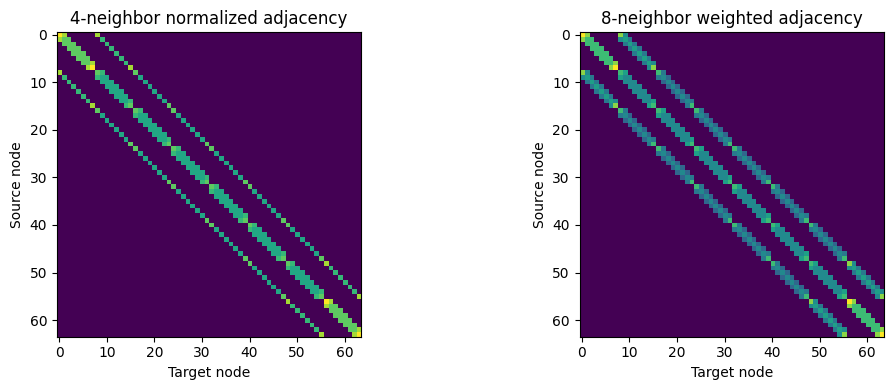

Nodes/image: 64 | CNN feature dimension/node: 128


In [7]:

# 6. Graph construction: 8×8 CNN-feature patch graph
# connectivity=4: horizontal/vertical neighbors
# connectivity=8: also diagonal neighbors
# weighted=True: diagonal edges receive 1/sqrt(2), axial edges 1.0

def make_grid_adjacency(grid=8, connectivity=4, weighted=False):
    n = grid * grid
    A = torch.eye(n, dtype=torch.float32)
    directions = [(1,0), (-1,0), (0,1), (0,-1)]
    if connectivity == 8:
        directions += [(1,1), (1,-1), (-1,1), (-1,-1)]
    for r in range(grid):
        for c in range(grid):
            i = r * grid + c
            for dr, dc in directions:
                rr, cc = r + dr, c + dc
                if 0 <= rr < grid and 0 <= cc < grid:
                    j = rr * grid + cc
                    w = 1.0
                    if weighted and abs(dr) + abs(dc) == 2:
                        w = 1 / np.sqrt(2)
                    A[i, j] = max(float(A[i, j]), w)
    d = A.sum(1).clamp_min(1e-8)
    D = torch.diag(d.pow(-0.5))
    return D @ A @ D

A4 = make_grid_adjacency(GRID, connectivity=4, weighted=False)
A8 = make_grid_adjacency(GRID, connectivity=8, weighted=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(A4.numpy())
axes[0].set_title("4-neighbor normalized adjacency")
axes[1].imshow(A8.numpy())
axes[1].set_title("8-neighbor weighted adjacency")
for ax in axes:
    ax.set_xlabel("Target node"); ax.set_ylabel("Source node")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "graph_adjacency_ablation.png", dpi=180)
plt.show()

print("Nodes/image:", GRID*GRID, "| CNN feature dimension/node: 128")


In [8]:

# 7. Models: CNN-only ablation, improved CNN-feature GCN, and ResNet18 baseline
class ConvBackbone(nn.Module):
    def __init__(self, out_grid=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d((out_grid, out_grid))
    def forward(self, x):
        return self.pool(self.features(x))  # B,128,G,G

class CNNOnly(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.backbone = ConvBackbone(GRID)
        self.head = nn.Sequential(
            nn.Dropout(0.35),
            nn.Linear(256, n_classes)
        )
    def forward(self, x):
        f = self.backbone(x)
        mean_pool = f.mean(dim=(2,3))
        max_pool = f.amax(dim=(2,3))
        return self.head(torch.cat([mean_pool, max_pool], dim=1))

class GraphConv(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim, bias=False)
    def forward(self, x, A):
        z = self.linear(x)
        return torch.einsum("ij,bjf->bif", A, z)

class NodeBatchNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.bn = nn.BatchNorm1d(dim)
    def forward(self, x):
        b, n, f = x.shape
        return self.bn(x.reshape(b*n, f)).reshape(b, n, f)

class CNNFeatureGCN(nn.Module):
    def __init__(self, n_classes, connectivity=8, weighted=True,
                 hidden=128, dropout=0.30, use_bn=True, depth=3):
        super().__init__()
        self.backbone = ConvBackbone(GRID)
        A = make_grid_adjacency(GRID, connectivity, weighted)
        self.register_buffer("A", A)
        self.use_bn = use_bn
        self.depth = depth

        self.g1 = GraphConv(128, hidden)
        self.g2 = GraphConv(hidden, hidden)
        self.g3 = GraphConv(hidden, hidden)
        self.bn1 = NodeBatchNorm(hidden)
        self.bn2 = NodeBatchNorm(hidden)
        self.bn3 = NodeBatchNorm(hidden)
        self.dropout = dropout
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, n_classes)
        )

    def image_to_nodes(self, x):
        f = self.backbone(x)                    # B,F,G,G
        return f.flatten(2).transpose(1, 2)     # B,N,F

    def _act(self, x, bn):
        if self.use_bn:
            x = bn(x)
        return F.relu(x)

    def forward_from_nodes(self, nodes):
        h1 = self._act(self.g1(nodes, self.A), self.bn1)
        h1 = F.dropout(h1, self.dropout, self.training)
        h2 = self._act(self.g2(h1, self.A), self.bn2)
        h2 = F.dropout(h2, self.dropout, self.training)
        if self.depth >= 3:
            h3 = self._act(self.g3(h2, self.A), self.bn3)
            h = h3 + h2                    # residual connection
        else:
            h = h2
        mean_pool = h.mean(1)
        max_pool = h.amax(1)
        return self.head(torch.cat([mean_pool, max_pool], dim=1))

    def forward(self, x):
        return self.forward_from_nodes(self.image_to_nodes(x))

class ResNet18Baseline(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        m = models.resnet18(weights=None)
        m.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        m.fc = nn.Linear(m.fc.in_features, n_classes)
        self.model = m
    def forward(self, x):
        return self.model(x)

print("Models ready.")


Models ready.


In [9]:

# 8. Training and full evaluation utilities
def full_evaluate(model, loader):
    model.eval()
    ys, preds, probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            p = torch.softmax(logits, dim=1)
            ys.append(y.numpy())
            preds.append(p.argmax(1).cpu().numpy())
            probs.append(p.cpu().numpy())
    y = np.concatenate(ys)
    pred = np.concatenate(preds)
    prob = np.concatenate(probs)
    macro = precision_recall_fscore_support(y, pred, average="macro", zero_division=0)
    weighted = precision_recall_fscore_support(y, pred, average="weighted", zero_division=0)
    y_bin = label_binarize(y, classes=np.arange(N_CLASSES))
    try:
        roc_auc = roc_auc_score(y_bin, prob, average="macro", multi_class="ovr")
    except Exception:
        roc_auc = np.nan
    try:
        ap = average_precision_score(y_bin, prob, average="macro")
    except Exception:
        ap = np.nan
    return {
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "precision_macro": macro[0], "recall_macro": macro[1], "f1_macro": macro[2],
        "precision_weighted": weighted[0], "recall_weighted": weighted[1], "f1_weighted": weighted[2],
        "roc_auc_macro_ovr": roc_auc, "average_precision_macro": ap,
        "actual": y, "predicted": pred, "probabilities": prob
    }

def model_size_mb(model):
    buff = io.BytesIO()
    torch.save(model.state_dict(), buff)
    return buff.getbuffer().nbytes / (1024**2)

def inference_ms_per_image(model, loader):
    model.eval()
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    n = 0
    with torch.no_grad():
        for x, y in loader:
            _ = model(x.to(device, non_blocking=True))
            n += len(y)
    if device.type == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) * 1000 / max(n, 1)

def train_model(name, model, train_loader, val_loader, epochs, lr=LR, patience=PATIENCE):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=1
    )
    best_state, best_f1 = None, -1
    wait = patience
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total = 0.0, 0
        for x, y in tqdm(train_loader, desc=f"{name} {epoch}/{epochs}", leave=False):
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * len(y)
            total += len(y)

        v = full_evaluate(model, val_loader)
        scheduler.step(v["f1_macro"])
        history.append({
            "model": name, "epoch": epoch,
            "train_loss": total_loss / max(total, 1),
            "val_accuracy": v["accuracy"],
            "val_macro_f1": v["f1_macro"]
        })
        print(f"{name} | epoch {epoch} | val acc={v['accuracy']:.4f} | macro-F1={v['f1_macro']:.4f}")

        if v["f1_macro"] > best_f1:
            best_f1 = v["f1_macro"]
            best_state = {k: t.detach().cpu().clone() for k, t in model.state_dict().items()}
            wait = patience
        else:
            wait -= 1
            if wait <= 0:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


In [10]:

# 9. Re-run the best Task 2 baseline (ResNet18) on the SAME fixed test split.
# This gives paired predictions required for McNemar.
resnet = ResNet18Baseline(N_CLASSES)
resnet, resnet_hist = train_model(
    "ResNet18_fixed", resnet, cnn_train_loader, cnn_val_loader,
    epochs=RESNET_EPOCHS, lr=1e-3
)
resnet_result = full_evaluate(resnet, cnn_test_loader)
resnet_result["model_size_mb"] = model_size_mb(resnet)
resnet_result["inference_ms_per_image"] = inference_ms_per_image(resnet, cnn_test_loader)
torch.save(resnet.state_dict(), OUTPUT_DIR / "Group01_MaleBin_resnet18_fixed.pt")

print({k: round(v,4) for k,v in resnet_result.items() if isinstance(v,(int,float,np.floating))})


ResNet18_fixed 1/6:   0%|          | 0/101 [00:00<?, ?it/s]

ResNet18_fixed | epoch 1 | val acc=0.5325 | macro-F1=0.5501


ResNet18_fixed 2/6:   0%|          | 0/101 [00:00<?, ?it/s]

ResNet18_fixed | epoch 2 | val acc=0.6698 | macro-F1=0.6448


ResNet18_fixed 3/6:   0%|          | 0/101 [00:00<?, ?it/s]

...

ResNet18_fixed | epoch 4 | val acc=0.7840 | macro-F1=0.7894


ResNet18_fixed 5/6:   0%|          | 0/101 [00:00<?, ?it/s]

ResNet18_fixed | epoch 5 | val acc=0.8158 | macro-F1=0.8084


ResNet18_fixed 6/6:   0%|          | 0/101 [00:00<?, ?it/s]

ResNet18_fixed | epoch 6 | val acc=0.8367 | macro-F1=0.8342
{'accuracy': 0.8347, 'balanced_accuracy': np.float64(0.8519), 'precision_macro': 0.8284, 'recall_macro': 0.8519, 'f1_macro': 0.8323, 'precision_weighted': 0.8513, 'recall_weighted': 0.8347, 'f1_weighted': 0.8365, 'roc_auc_macro_ovr': np.float64(0.9892), 'average_precision_macro': np.float64(0.8866), 'model_size_mb': 42.7557, 'inference_ms_per_image': 1.3926}


In [11]:

# 10. Ablation study
# A: CNN backbone only (graph OFF)
# B: CNN + GCN with 4-neighbor graph
# C: CNN + GCN with 8-neighbor weighted graph (proposed improved model)
# D: same final graph but batch normalization OFF

ablation_builders = {
    "CNN_only_no_graph": lambda: CNNOnly(N_CLASSES),
    "CNN_GCN_4N": lambda: CNNFeatureGCN(N_CLASSES, connectivity=4, weighted=False, use_bn=True, depth=3),
    "CNN_GCN_8N_weighted": lambda: CNNFeatureGCN(N_CLASSES, connectivity=8, weighted=True, use_bn=True, depth=3),
    "CNN_GCN_8N_noBN": lambda: CNNFeatureGCN(N_CLASSES, connectivity=8, weighted=True, use_bn=False, depth=3),
}

ablation_models, ablation_results, histories = {}, {}, [resnet_hist]

for name, builder in ablation_builders.items():
    model, hist = train_model(
        name, builder(), graph_train_loader, graph_val_loader,
        epochs=FIXED_EPOCHS, lr=LR
    )
    result = full_evaluate(model, graph_test_loader)
    result["model_size_mb"] = model_size_mb(model)
    result["inference_ms_per_image"] = inference_ms_per_image(model, graph_test_loader)
    ablation_models[name] = model
    ablation_results[name] = result
    histories.append(hist)
    print(name, "macro-F1 =", round(result["f1_macro"], 4))

history_all = pd.concat(histories, ignore_index=True)
history_all.to_csv(OUTPUT_DIR / "task3_training_history.csv", index=False)

# Final GCN is the best GCN variant, not the CNN-only ablation.
gcn_names = [n for n in ablation_results if "GCN" in n]
FINAL_NAME = max(gcn_names, key=lambda n: ablation_results[n]["f1_macro"])
final_model = ablation_models[FINAL_NAME]
final_result = ablation_results[FINAL_NAME]

print("\nSelected final GCN:", FINAL_NAME, "| macro-F1:", round(final_result["f1_macro"],4))


CNN_only_no_graph 1/5:   0%|          | 0/101 [00:00<?, ?it/s]

CNN_only_no_graph | epoch 1 | val acc=0.6308 | macro-F1=0.5582


CNN_only_no_graph 2/5:   0%|          | 0/101 [00:00<?, ?it/s]

CNN_only_no_graph | epoch 2 | val acc=0.7081 | macro-F1=0.6534


CNN_only_no_graph 3/5:   0%|          | 0/101 [00:00<?, ?it/s]

...

CNN_GCN_8N_noBN | epoch 4 | val acc=0.7088 | macro-F1=0.6525


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78e0ab930720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x78e0ab930720>
^^Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    
self._shutdown_workers()  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        assert self._parent_pid == os.getpid(), 'can only test a child process'if w.is_alive():

                ^ ^ ^^^^^^^^^^^^^^^^^^^
^  

CNN_GCN_8N_noBN 5/5:   0%|          | 0/101 [00:01<?, ?it/s]

^^
AssertionError^: ^can only test a child process^
^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x78e0ab930720>^^^

Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        assert self._parent_pid == os.getpid(), 'can only test a child process'self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
       if w.is_alive():  
          ^   ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    assert self._parent_pid == os.getpid(), 'can only test a child process'
 ^ ^^ ^ ^^^ ^^ ^ ^^ ^^  ^ ^^^^^^^^^
^AssertionError: ^can only test a child process^
^^^^^^^^^^^^^^^^^^^^^^^^
: AssertionErrorcan only test a child process


CNN_GCN_8N_noBN | epoch 5 | val acc=0.7146 | macro-F1=0.7019
CNN_GCN_8N_noBN macro-F1 = 0.7199

Selected final GCN: CNN_GCN_4N | macro-F1: 0.7857


,model,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,precision_weighted,recall_weighted,roc_auc_macro_ovr,average_precision_macro,model_size_mb,inference_ms_per_image
0,Task2_ResNet18,0.8664,0.8811,0.8615,0.8648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Task2_First_PatchGCN,0.4433,0.5080,0.3771,0.3887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ResNet18_fixed,0.8347,0.8519,0.8323,0.8365,0.8284,0.8519,0.8513,0.8347,0.9892,0.8866,42.7557,1.3926
3,CNN_only_no_graph,0.7487,0.7571,0.7191,0.7347,0.7232,0.7571,0.7589,0.7487,0.9737,0.7873,0.3972,1.1240
4,CNN_GCN_4N,0.7884,0.8076,0.7857,0.7857,0.8168,0.8076,0.8406,0.7884,0.9789,0.8316,0.6119,1.2020
5,CNN_GCN_8N_weighted,0.7762,0.7852,0.7645,0.7703,0.7672,0.7852,0.7812,0.7762,0.9804,0.8211,0.6119,1.1809
6,CNN_GCN_8N_noBN,0.7285,0.7554,0.7199,0.7223,0.7292,0.7554,0.7568,0.7285,0.9661,0.7738,0.6119,1.1450


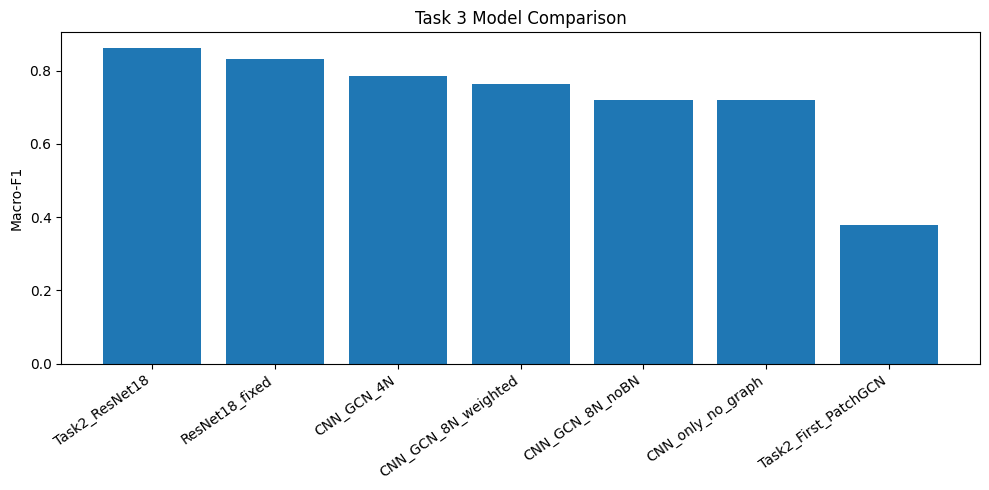

In [12]:

# 11. Final comparison table
# Task 2 values are included only as historical results from the previous executed notebook.
task2_history = pd.DataFrame([
    {"model":"Task2_ResNet18", "accuracy":0.8664, "balanced_accuracy":0.8811, "f1_macro":0.8615, "f1_weighted":0.8648},
    {"model":"Task2_First_PatchGCN", "accuracy":0.4433, "balanced_accuracy":0.5080, "f1_macro":0.3771, "f1_weighted":0.3887},
])

def numeric_row(name, result):
    keep = [
        "accuracy","balanced_accuracy","precision_macro","recall_macro","f1_macro",
        "precision_weighted","recall_weighted","f1_weighted",
        "roc_auc_macro_ovr","average_precision_macro",
        "model_size_mb","inference_ms_per_image"
    ]
    return {"model":name, **{k:result.get(k,np.nan) for k in keep}}

current_rows = [numeric_row("ResNet18_fixed", resnet_result)]
current_rows += [numeric_row(n, r) for n,r in ablation_results.items()]
comparison = pd.concat([task2_history, pd.DataFrame(current_rows)], ignore_index=True, sort=False)
comparison.to_csv(OUTPUT_DIR / "task3_model_comparison.csv", index=False)

display(comparison.round(4))

plt.figure(figsize=(10,5))
plot_df = comparison.dropna(subset=["f1_macro"]).sort_values("f1_macro", ascending=False)
plt.bar(plot_df.model, plot_df.f1_macro)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Macro-F1")
plt.title("Task 3 Model Comparison")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task3_macro_f1_comparison.png", dpi=180)
plt.show()


,precision,recall,f1-score,support
Malware_Merge/Adialer.C,1.000,1.000,1.000,6.000
Malware_Merge/Agent.FYI,1.000,1.000,1.000,17.000
Malware_Merge/Allaple.A,1.000,0.900,0.947,150.000
Malware_Merge/Allaple.L,0.962,1.000,0.980,150.000
Malware_Merge/Alueron.gen!J,1.000,1.000,1.000,30.000
Malware_Merge/C2LOP.P,0.760,0.864,0.809,22.000
Malware_Merge/C2LOP.gen!g,1.000,0.833,0.909,30.000
Malware_Merge/CoinMinerXMRig,0.184,0.318,0.233,22.000
Malware_Merge/Danabot,0.909,0.400,0.556,75.000
Malware_Merge/Dialplatform.B,1.000,1.000,1.000,27.000


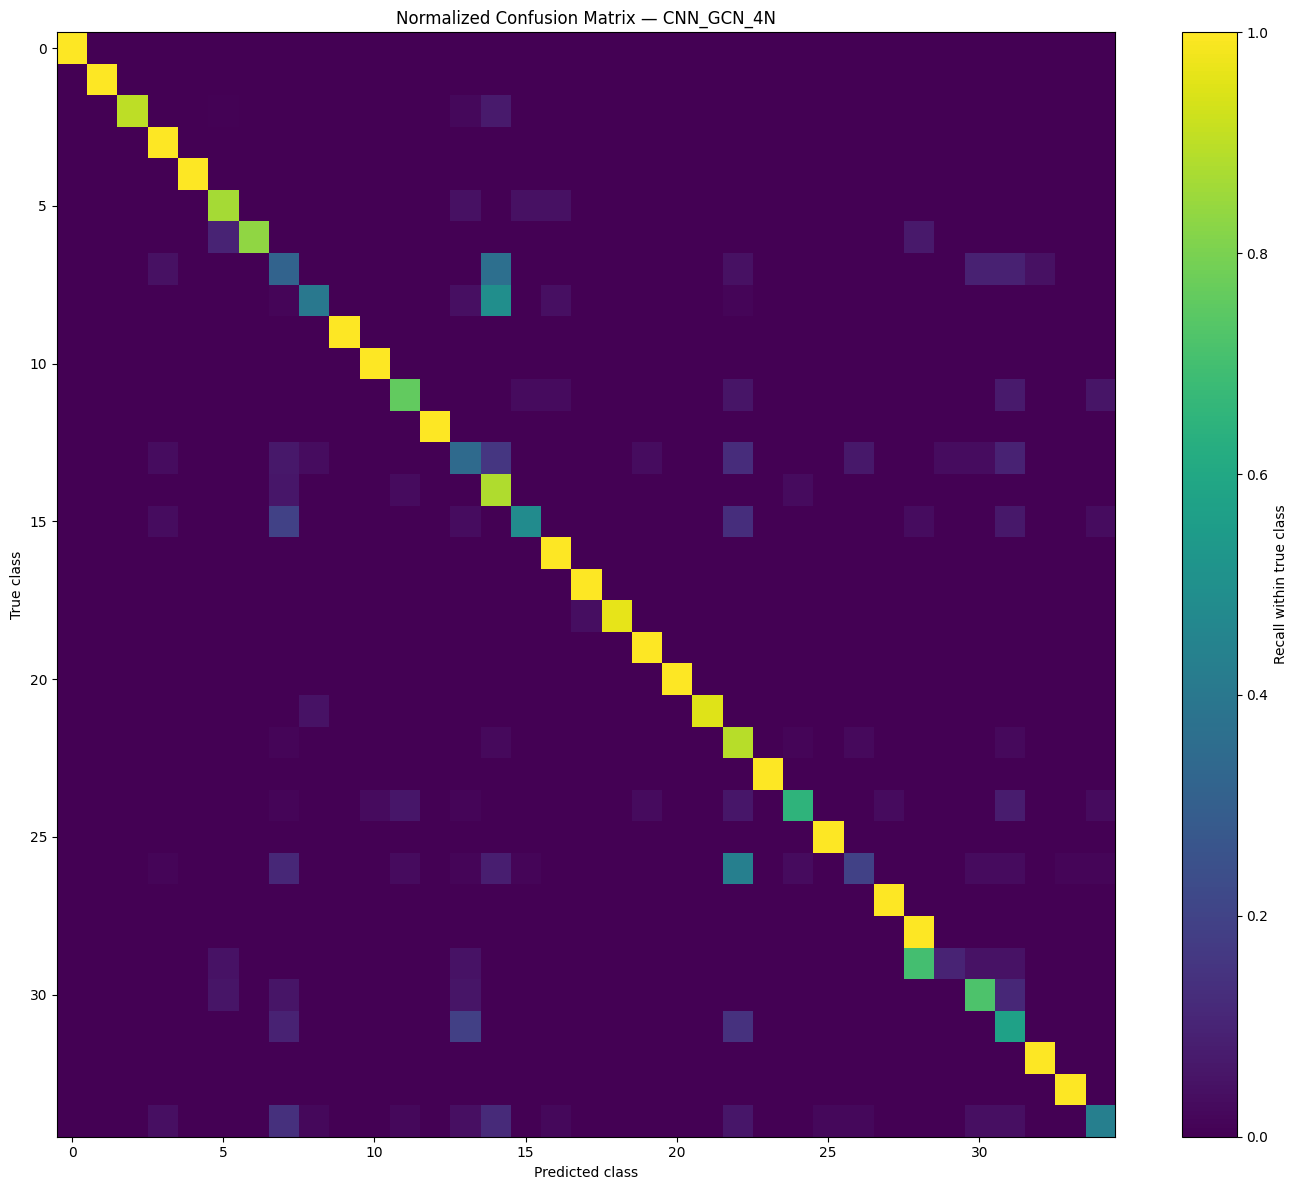

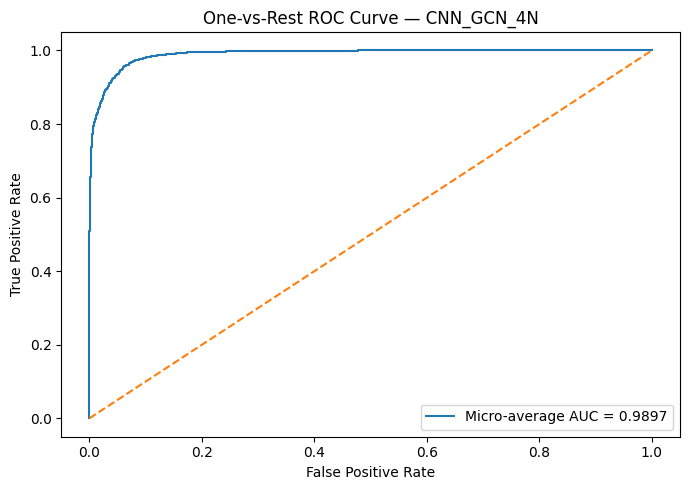

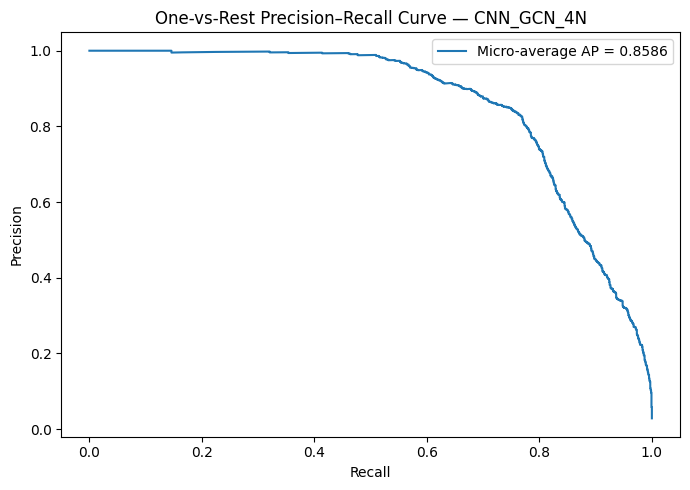

Macro OvR ROC-AUC: 0.9789
Macro average precision: 0.8316


In [13]:

# 12. Full report for final GCN + confusion matrix + multiclass ROC/PR curves
report = pd.DataFrame(classification_report(
    final_result["actual"], final_result["predicted"],
    target_names=encoder.classes_, output_dict=True, zero_division=0
)).T
report.to_csv(OUTPUT_DIR / "final_gcn_classification_report.csv")
display(report.round(3))

cm = confusion_matrix(final_result["actual"], final_result["predicted"], normalize="true")
plt.figure(figsize=(14,12))
plt.imshow(cm, aspect="auto", interpolation="nearest")
plt.colorbar(label="Recall within true class")
plt.title(f"Normalized Confusion Matrix — {FINAL_NAME}")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_gcn_confusion_matrix.png", dpi=180)
plt.show()

# One-vs-rest micro-average ROC and PR for multiclass
y = final_result["actual"]
prob = final_result["probabilities"]
y_bin = label_binarize(y, classes=np.arange(N_CLASSES))

fpr, tpr, _ = roc_curve(y_bin.ravel(), prob.ravel())
roc_micro = auc(fpr, tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"Micro-average AUC = {roc_micro:.4f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"One-vs-Rest ROC Curve — {FINAL_NAME}")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_gcn_roc_curve.png", dpi=180)
plt.show()

precision, recall, _ = precision_recall_curve(y_bin.ravel(), prob.ravel())
ap_micro = average_precision_score(y_bin, prob, average="micro")
plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"Micro-average AP = {ap_micro:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"One-vs-Rest Precision–Recall Curve — {FINAL_NAME}")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_gcn_precision_recall_curve.png", dpi=180)
plt.show()

print("Macro OvR ROC-AUC:", round(final_result["roc_auc_macro_ovr"],4))
print("Macro average precision:", round(final_result["average_precision_macro"],4))


In [14]:

# 13. McNemar significance test: final GCN vs ResNet18 on SAME held-out test samples
# Both loaders use the same test_df order, so predictions are paired.

base_correct = (resnet_result["predicted"] == resnet_result["actual"])
final_correct = (final_result["predicted"] == final_result["actual"])

# b = baseline correct, final wrong
# c = baseline wrong, final correct
b = int(np.sum(base_correct & ~final_correct))
c = int(np.sum(~base_correct & final_correct))

if b + c == 0:
    p_value = 1.0
else:
    p_value = binomtest(min(b,c), n=b+c, p=0.5, alternative="two-sided").pvalue

mcnemar_table = pd.DataFrame({
    "Final GCN wrong":[int(np.sum(base_correct & ~final_correct)), int(np.sum(~base_correct & ~final_correct))],
    "Final GCN correct":[int(np.sum(base_correct & final_correct)), int(np.sum(~base_correct & final_correct))]
}, index=["ResNet correct","ResNet wrong"])

display(mcnemar_table)
print(f"Discordant pairs: b={b}, c={c}")
print(f"Exact McNemar/binomial p-value = {p_value:.6f}")
print("Significant at alpha=0.05:", p_value < 0.05)

pd.DataFrame([{
    "test":"Exact McNemar (binomial form)",
    "b_baseline_correct_final_wrong":b,
    "c_baseline_wrong_final_correct":c,
    "p_value":p_value,
    "significant_alpha_0_05":p_value < 0.05
}]).to_csv(OUTPUT_DIR / "mcnemar_test.csv", index=False)


,Final GCN wrong,Final GCN correct
ResNet correct,128,1028
ResNet wrong,165,64


Discordant pairs: b=128, c=64
Exact McNemar/binomial p-value = 0.000004
Significant at alpha=0.05: True


In [15]:

# 14. Required 5-fold stratified CV
# For image deep learning this is expensive, so FAST_MODE uses only 3 epochs/fold.
# The same fold indices are used for both models.

def make_fold_loaders(train_fold, test_fold, graph=True):
    # create a validation split only from the fold's training portion
    tr, va = train_test_split(
        train_fold, test_size=0.12, stratify=train_fold.label_id, random_state=SEED
    )
    if graph:
        return (
            balanced_loader(tr, graph_train_tf),
            plain_loader(va, graph_eval_tf),
            plain_loader(test_fold, graph_eval_tf)
        )
    else:
        return (
            balanced_loader(tr, cnn_train_tf),
            plain_loader(va, cnn_eval_tf),
            plain_loader(test_fold, cnn_eval_tf)
        )

cv_rows = []

if RUN_5FOLD:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    clean_cv = clean.reset_index(drop=True)

    # Use the selected final architecture settings.
    final_is_4n = FINAL_NAME == "CNN_GCN_4N"
    final_is_nobn = FINAL_NAME == "CNN_GCN_8N_noBN"
    final_connectivity = 4 if final_is_4n else 8
    final_weighted = False if final_is_4n else True
    final_use_bn = not final_is_nobn

    for fold, (tr_idx, te_idx) in enumerate(skf.split(clean_cv, clean_cv.label_id), 1):
        print(f"\n========== Fold {fold}/5 ==========")
        fold_train = clean_cv.iloc[tr_idx].copy()
        fold_test = clean_cv.iloc[te_idx].copy()

        # ResNet18
        trL, vaL, teL = make_fold_loaders(fold_train, fold_test, graph=False)
        bmodel, _ = train_model(
            f"CV{fold}_ResNet18", ResNet18Baseline(N_CLASSES),
            trL, vaL, epochs=CV_EPOCHS, lr=1e-3, patience=1
        )
        br = full_evaluate(bmodel, teL)
        cv_rows.append({"fold":fold, "model":"ResNet18", **{
            k:br[k] for k in ["accuracy","balanced_accuracy","precision_macro","recall_macro","f1_macro","f1_weighted","roc_auc_macro_ovr","average_precision_macro"]
        }})
        del bmodel
        if torch.cuda.is_available(): torch.cuda.empty_cache()

        # Final GCN
        trL, vaL, teL = make_fold_loaders(fold_train, fold_test, graph=True)
        gmodel = CNNFeatureGCN(
            N_CLASSES, connectivity=final_connectivity,
            weighted=final_weighted, use_bn=final_use_bn, depth=3
        )
        gmodel, _ = train_model(
            f"CV{fold}_{FINAL_NAME}", gmodel,
            trL, vaL, epochs=CV_EPOCHS, lr=LR, patience=1
        )
        gr = full_evaluate(gmodel, teL)
        cv_rows.append({"fold":fold, "model":"Final_GCN", **{
            k:gr[k] for k in ["accuracy","balanced_accuracy","precision_macro","recall_macro","f1_macro","f1_weighted","roc_auc_macro_ovr","average_precision_macro"]
        }})
        del gmodel
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    cv_df = pd.DataFrame(cv_rows)
    cv_df.to_csv(OUTPUT_DIR / "five_fold_cv_raw.csv", index=False)
    display(cv_df.round(4))

    metrics = ["accuracy","balanced_accuracy","precision_macro","recall_macro","f1_macro","f1_weighted","roc_auc_macro_ovr","average_precision_macro"]
    summary_rows = []
    for model_name, group in cv_df.groupby("model"):
        row = {"model":model_name}
        for m in metrics:
            row[m+"_mean"] = group[m].mean()
            row[m+"_std"] = group[m].std(ddof=1)
        summary_rows.append(row)
    cv_summary = pd.DataFrame(summary_rows)
    cv_summary.to_csv(OUTPUT_DIR / "five_fold_cv_mean_std.csv", index=False)
    display(cv_summary.round(4))

    base_f1 = cv_df[cv_df.model=="ResNet18"].sort_values("fold").f1_macro.to_numpy()
    gcn_f1 = cv_df[cv_df.model=="Final_GCN"].sort_values("fold").f1_macro.to_numpy()
    try:
        stat, p = wilcoxon(gcn_f1, base_f1, alternative="two-sided")
    except ValueError:
        stat, p = np.nan, 1.0
    print("Wilcoxon signed-rank across 5 fold macro-F1 values")
    print("Statistic:", stat, "| p-value:", p, "| significant @0.05:", p < 0.05)
    pd.DataFrame([{
        "test":"Wilcoxon signed-rank on 5-fold macro-F1",
        "statistic":stat, "p_value":p, "significant_alpha_0_05":p < 0.05
    }]).to_csv(OUTPUT_DIR / "wilcoxon_cv_test.csv", index=False)
else:
    print("RUN_5FOLD=False. For final submission, Task 3 asks for 5-fold CV if affordable.")



========== Fold 1/5 ==========


CV1_ResNet18 1/3:   0%|          | 0/102 [00:00<?, ?it/s]

CV1_ResNet18 | epoch 1 | val acc=0.6516 | macro-F1=0.5696


CV1_ResNet18 2/3:   0%|          | 0/102 [00:00<?, ?it/s]

CV1_ResNet18 | epoch 2 | val acc=0.6787 | macro-F1=0.6409


...

CV5_CNN_GCN_4N 3/3:   0%|          | 0/102 [00:00<?, ?it/s]

CV5_CNN_GCN_4N | epoch 3 | val acc=0.7655 | macro-F1=0.7469


,fold,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_macro_ovr,average_precision_macro
0,1,ResNet18,0.6289,0.6851,0.7415,0.6851,0.6507,0.6075,0.9750,0.8142
1,1,Final_GCN,0.7199,0.7067,0.7489,0.7067,0.6673,0.7037,0.9715,0.7853
2,2,ResNet18,0.6750,0.7521,0.7734,0.7521,0.7358,0.6913,0.9732,0.8289
3,2,Final_GCN,0.7096,0.7097,0.7194,0.7097,0.6748,0.6850,0.9729,0.7810
4,3,ResNet18,0.7931,0.8049,0.7831,0.8049,0.7684,0.7813,0.9850,0.8495
5,3,Final_GCN,0.7064,0.6840,0.6335,0.6840,0.6119,0.6761,0.9623,0.7382
6,4,ResNet18,0.7936,0.8053,0.7826,0.8053,0.7768,0.7857,0.9807,0.8260
7,4,Final_GCN,0.7378,0.7492,0.7371,0.7492,0.6986,0.7236,0.9746,0.7983
8,5,ResNet18,0.7486,0.7797,0.7283,0.7797,0.7230,0.7403,0.9769,0.8060
9,5,Final_GCN,0.7784,0.7948,0.7825,0.7948,0.7617,0.7632,0.9811,0.8283


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,roc_auc_macro_ovr_mean,roc_auc_macro_ovr_std,average_precision_macro_mean,average_precision_macro_std
0,Final_GCN,0.7304,0.0295,0.7289,0.0437,0.7243,0.0557,0.7289,0.0437,0.6829,0.0543,0.7103,0.0347,0.9725,0.0068,0.7862,0.0326
1,ResNet18,0.7278,0.0735,0.7654,0.0499,0.7618,0.0253,0.7654,0.0499,0.7309,0.0501,0.7212,0.0741,0.9782,0.0047,0.8249,0.0165


Wilcoxon signed-rank across 5 fold macro-F1 values
Statistic: 3.0 | p-value: 0.3125 | significant @0.05: False


In [16]:

# 15. Related-work context
# The reviewed studies use different datasets and experimental protocols, so their reported scores
# are summarized qualitatively rather than treated as direct numerical comparisons with MaleBin.

related_work = pd.DataFrame([
    ["Self-Supervised Vision Transformers for Malware Detection", 2022, "AndroZoo", "ViT", "No"],
    ["Grayscale Image-Based Deep Learning Model for Efficient and Scalable Malware Detection", 2025, "MalImg", "CNN", "No"],
    ["Multimodal Malware Classification Using Proposed Ensemble Deep Neural Network Framework", 2025, "Android malware dataset", "Ensemble DNN", "No"],
    ["YoloMal-XAI", 2025, "CICMalDroid2020", "YOLO11 + XAI", "No"],
    ["Hybrid Noise-Resistant Technique for Malware Classification", 2026, "BODMAS", "CAE + LBP + XGBoost", "No"],
], columns=["Paper","Year","Dataset","Method","Directly_comparable_to_MaleBin"])

related_work["Fair_comparison_note"] = (
    "Different dataset/protocol; qualitative comparison only."
)
related_work.to_csv(OUTPUT_DIR / "related_work_fairness_table.csv", index=False)
display(related_work)


,Paper,Year,Dataset,Method,Directly_comparable_to_MaleBin,Fair_comparison_note
0,Self-Supervised Vision Transformers for Malwar...,2022,AndroZoo,ViT,No,Different dataset/protocol; discuss qualitativ...
1,Grayscale Image-Based Deep Learning Model for ...,2025,MalImg,CNN,No,Different dataset/protocol; discuss qualitativ...
2,Multimodal Malware Classification Using Propos...,2025,Android malware dataset,Ensemble DNN,No,Different dataset/protocol; discuss qualitativ...
3,YoloMal-XAI,2025,CICMalDroid2020,YOLO11 + XAI,No,Different dataset/protocol; discuss qualitativ...
4,Hybrid Noise-Resistant Technique for Malware C...,2026,BODMAS,CAE + LBP + XGBoost,No,Different dataset/protocol; discuss qualitativ...


In [17]:

# 16. Save final GCN model and experiment configuration
torch.save(final_model.state_dict(), OUTPUT_DIR / "Group01_MaleBin_best_gcn.pt")

final_config = {
    "final_name": FINAL_NAME,
    "n_classes": N_CLASSES,
    "grid": GRID,
    "graph_image_size": GRAPH_IMAGE_SIZE,
    "connectivity": 4 if FINAL_NAME=="CNN_GCN_4N" else 8,
    "weighted": False if FINAL_NAME=="CNN_GCN_4N" else True,
    "use_bn": False if FINAL_NAME=="CNN_GCN_8N_noBN" else True,
    "depth": 3,
    "fixed_test_macro_f1": float(final_result["f1_macro"]),
    "fixed_test_accuracy": float(final_result["accuracy"]),
    "resnet_fixed_macro_f1": float(resnet_result["f1_macro"]),
}
with open(OUTPUT_DIR / "final_model_config.json", "w") as f:
    json.dump(final_config, f, indent=2)

print("Saved Task 3 outputs to:", OUTPUT_DIR)
print("Final model:", FINAL_NAME)


Saved Task 3 outputs to: /kaggle/working/task3_outputs
Final model: CNN_GCN_4N
